# Chapter 3: Visual Programming of Tables of Data

## Notes

- All our previous widget’s have largely been static
- Next we’ll examine how we can represent data in graphical user
  interface
- Throughout the chapter we’ll use the following data table for US
  states

| State      | Abbrev | Capital     | Founded |
|------------|--------|-------------|---------|
| Alabama    | AL     | Montgomery  | 1819    |
| Alaska     | AK     | Juneau      | 1960    |
| Arizona    | AZ     | Phoenix     | 1912    |
| Arkansas   | AR     | Little Rock | 1836    |
| California | CA     | Sacramento  | 1850    |

- We start by reading this data from a [csv
  file](Examples/sample_data.csv)
  - We can write a simple generator function to do this using the `csv`
    built-in library
  - This returns the header tuple and the data rows as two separate
    objects

In [1]:
import csv


def generate_csv(file_path):
    with open(file_path, newline="") as csv_file:
        csv_reader = csv.reader(csv_file)
        for row in csv_reader:
            yield tuple(row)


csv_data = generate_csv("Examples/sample_data.csv")
header, *rows = csv_data
print("\n".join([str(row) for row in rows]))

('Alabama', 'AL', 'Montgomery', '1819', ' 198218')
('Alaska', 'AK', 'Juneau', '1960', ' 31275')
('Arizona', 'AZ', 'Phoenix', '1912', ' 1660272')
('Arkansas', 'AR', 'Little Rock', '1836', ' 193524')
('California', 'CA', 'Sacramento', '1850', ' 508524')
('Colorado', 'CO', 'Denver', '1876', ' 716492')
('Connecticut', 'CT', 'Hartford', '1788', ' 124775')
('Delaware', 'DE', 'Dover', '1787', ' 36047')
('Florida', 'FL', 'Tallahassee', '1845', ' 181376')
('Georgia', 'GA', 'Atlanta', '1788', ' 498044')
('Hawaii', 'HI', 'Honolulu', '1959', ' 359870')
('Idaho', 'ID', 'Boise', '1890', ' 205671')
('Illinois', 'IL', 'Springfield', '1818', ' 116250')
('Indiana', 'IN', 'Indianapolis', '1816', ' 867125')
('Iowa', 'IA', 'Des Moines', '1846', ' 203433')
('Kansas', 'KS', 'Topeka', '1861', ' 127473')
('Kentucky', 'KY', 'Frankfort', '1792', ' 25527')
('Louisiana', 'LA', 'Baton Rouge', '1812', ' 225374')
('Maine', 'ME', 'Augusta', '1820', ' 19136')
('Maryland', 'MD', 'Annapolis', '1788', ' 38394')
('Massachu

- Next we want to create a state object for each row in the csv that
  captures the relevant information
  - `State` is a simple `dataclass` that just holds attributes
    corresponding to the table data
  - We’ll define a class `StateList` that combines loading the state
    information and creation of the state objects
    - This is done the in the `__init__`

In [2]:
import dataclasses


@dataclasses.dataclass
class State:
    name: str
    abbrev: str
    capital: str
    founded: str


class StatesList:
    def __init__(self, states_file):
        header, *rows = generate_csv(states_file)
        self._states = [State(*row) for row in rows]


states = StatesList("Examples/sample_data.csv")
print("\n".join([str(state) for state in states._states]))

- Now that we’ve got our data loaded we can start to look at how we
  might display it

### Creating a Listbox

- A `Listbox` is a widget that let’s the user select from a drop-down
  menu of strings
- This can be made pretty easily out of the box

``` python
import tkinter as tk

class UIBuilder():
    def __init__(self, root, states_list):
        self.states = states_list
        self.listbox = tk.Listbox(root, selectmode=tk.SINGLE)
        self.listbox.grid(column=0, row=0, rowspan=4, padx=10)
        for state in self.states:
            self.listbox.insert(tk.END, state.name)
```

- To add options to the `Listbox` we call the `insert` method

  - The first argument is where to insert the string
    - `tk.END` is a special constant to indicate it should be appended
  - The second argument is the string to insert

- `Listbox` supports multiple different selection modes (`selectmode`)

  - `tk.SINGLE`
    - One item can be selected at a time by clicking
  - `tk.BROWSE`
    - The selection can be moved with the mouse
  - `tk.MULTIPLE`
    - Multiple elements can be selected
  - `tk.EXTENDED`
    - Multiple groups can be selected using the CTRL and Shift keys

- The full code can be found at
  [01-listbox.py](Examples/01-Listbox/01-listbox.py) and should produce
  a widget that looks like below

  <figure>
  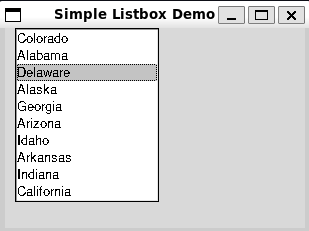
  <figcaption aria-hidden="true">A simple Listbox containing the names of
  US states</figcaption>
  </figure>

#### Adding a Scroll Bar

- A simple quality of life improvement would be to add a scroll bar
- Tkinter provides the `Scrollbar` widget
  - We just need to create it and then bind it to the `Listbox`
- We add the following to the `UIBuilder` class `__init__` method (See
  [02-scrollbar.py](Examples/02-Scrollbar/02-scrollbar.py) for the full
  program)

``` python
# create scrollbar and link to the listbox
scrollbar = tk.Scrollbar(root, command=self.listbox.yview)
scrollbar.grid(row=0, column=1, rowspan=4, sticky=tk.N + tk.S)

# make it so scrolling on the listbox adjusts the scroll bar in turn
self.listbox.config(yscrollcommand=scrollbar.set)
```

- As seen below, the program now contains a synchronised scroll bar

  <figure>
  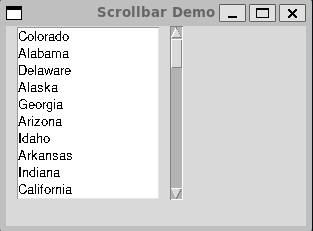
  <figcaption aria-hidden="true">Our Listbox has now been augmented with
  synchronised scroll bar</figcaption>
  </figure>

#### Displaying the State Data

- Now we have a List box and associated scroll bar to select a state,
  but nothing happens when we do

- We want to associated state information to be displayed when we select
  a state

- The most basic implementation is to do so with labels whose text is
  tied to the data values

- We’ll do a general clean-up of the code base too while doing this

- We add a method here that converts the `State` object to a dictionary
  matching the `key:value` structure of the csv

  - i.e. It maps the column headers to their respective values

  ``` python
    @dataclasses.dataclass
    class State:
        name: str
        abbrev: str
        capital: str
        founded: str

        def to_dict(self):
            return {
                "State": self.name,
                "Abbrev": self.abbrev,
                "Capital": self.capital,
                "Founded": self.founded,
            }
  ```

- We’ve also renamed our `StatesList` class to `StatesLoader` to reflect
  that it only has responsibility for loading the data from a file

- Once that’s done we can retrieve the headers and the list itself and
  work with those directly

- The next step is to create the labels

  - We iterate over the headers loaded by `StatesLoader` and generate a
    header for each
  - They are stored in a dictionary keyed by the column name
  - For the abbreviation we’ll specifically set that to appear red as
    well
  - To update the labels when the list box is changed, we need to bind a
    function to the signal
    - Tkinter provides a range of different events that can be bound to
    - Check out the
      [documentation](https://docs.python.org/3/library/tkinter.html#module-tkinter)
      for all of them

    ``` python
        # create labels for data in the state list
        self.state_labels = {
            column_name: tk.Label(root, text="") for column_name in self.header
        }
        try:
            self.state_labels["Abbrev"].config(fg="red")
        except KeyError:
            pass

        for idx, label in enumerate(self.state_labels.values()):
            label.grid(column=2, row=idx, sticky=tk.W)

        self.listbox.bind("<<ListboxSelect>>", self.state_selected)
    ```

- Then the last step is to define the function that is actually bound

  - Here we use the fact that the keys are synchronised between the
    `state_labels` dictionary and the `state` class do this with a
    simple `for` loop

  ``` python
    def state_selected(self, event):
        idx = int(self.listbox.curselection()[0])
        state = self.states[idx]

        for key, val in state.to_dict().items():
            self.state_labels[key].config(text=val)
  ```

- The resulting program should now look like below, and can be found in
  [03-display-state-data.py](Examples/03-display-state-data/03-display-state-data.py)

- A nice feature to have might be the ability to jump through a list to
  a letter by pressing the corresponding key

  - We can do this via an `Entry` field
    - We then bind the `<Key>` event on the entry field (corresponding
      to a key being entered) to a new function

    ``` python
      # create Entry so that we can jump alphabetically
      self.entry = tk.Entry(root)
      self.entry.grid(column=0, row=4, pady=4)
      self.entry.focus_set()  # makes this the focus of the window
      self.entry.bind("<Key>", self.key_press)
    ```
  - Now again just have to define the bound function
    - Here we want,
      1.  *to clear* the entry box so only most recent letter is shown
      2.  Clear the existing `Listbox` selection
      3.  Set the new selection
      4.  Ensure the new selection is visible on the widget
      5.  Update the displayed data

    ``` python
      def key_press(self, event):
          char = event.char.upper()

          def find_closest():
              idx = bisect.bisect_left(self.states, char, key=lambda x: x.name)
              if idx != len(self.states):
                  return idx
              return 0

          idx = find_closest()

          # reset the entry
          self.entry.delete(0, tk.END)

          # Update the listbox to the new selection, discarding the old and scrolling so its visible
          self.listbox.select_clear(0, tk.END)
          self.listbox.select_set(idx)
          self.listbox.see(idx)

          # call the function triggered a new selection
          self.state_selected(event)
    ```

- The final program given in
  [04-bind-key-press.py](Examples/04-bind-key-press/04-bind-key-press.py)
  should look like the below,

  <figure>
  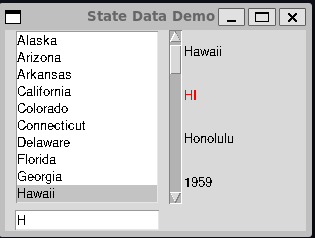
  <figcaption aria-hidden="true">Our simple state data widget now has an
  entry, entering <em>H</em> should immediately skip down to
  <em>Hawaii</em></figcaption>
  </figure>

### Using a Combobox

- A `Combobox` is like a `Listbox` but rather than being a simple
  drop-down it combines that with an `Entry`

  - Provided as part of the `ttk` submodule
  - The user can type to specify elements from the drop-down or write
    something entirely new

- We can rewrite our state data program to use a `Combobox` instead of a
  `Listbox`

  - `Combobox` has it’s own scrollbar so we don’t need to add one
    ourselves
  - By binding on `<<ComboBoxSelected>>` we only trigger when the user
    selects an option from the drop-down

  ``` python
    class UIBuilder:
        def __init__(self, root, states_loader):

            states_loader = states_loader
            self.states = states_loader.states
            self.header = states_loader.header

            self.combo = tk.ttk.Combobox(root, values=[state.name for state in self.states])
            self.combo.current(0)
            self.combo.bind("<<ComboboxSelected>>", self.state_selected)
            self.combo.grid(column=0, row=0, rowspan=8, padx=10)

            # create labels for data in the state list
            self.state_labels = {
                column_name: tk.Label(root, text="") for column_name in self.header
            }
            try:
                self.state_labels["Abbrev"].config(fg="red")
            except KeyError:
                pass

            for idx, label in enumerate(self.state_labels.values()):
                label.grid(column=2, row=idx, sticky=tk.W)

            self.state_selected(None)

        def state_selected(self, event):

            state = self.states[self.combo.current()]
            self.update_labels(state)

        def update_labels(self, state):

            for key, val in state.to_dict().items():
                self.state_labels[key].config(text=val)
  ```

- As with previous examples the full code can be found in
  [05-combobox.py](Examples/05-Combobox/05-combobox.py)

- The program should look similar to below

  <figure>
  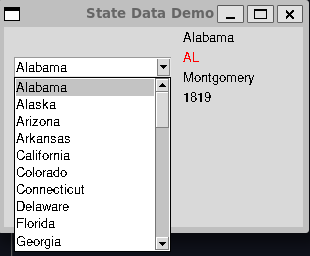
  <figcaption aria-hidden="true">The state data widget with the
  <code>ListBox</code> swapped out for a
  <code>ComboBox</code></figcaption>
  </figure>

### The Treeview Widget

- The `Treeview` widget is designed to view nested or tabular data

  - A `Treeview` table is a top row of headers, followed by a data rows
    like a CSV

  | **Header #0** | **Header** | **Header** | **Header** |
  |---------------|------------|------------|------------|
  | Labels        |            |            |            |
  | or text col   |            |            |            |

  - Leftmost column is always named `"#0"`
    - Can contain,
      1.  Labels for the rows
      2.  Data

- Row’s can be constructed as children of other rows

  - This is how you create a nested tree structure

- Let’s consider displaying our state data using a `Treeview`

- First we need to create our columns

  - The state name goes in the first column
  - The remaining columns we create by iterating over the remaining
    headers
  - We set the `width` and `minwidth` values in pixels
  - Then set `stretch=tk.NO` to stop the widget resizing columns

  ``` python
    states_loader: StatesLoader = states_loader
        self.states = states_loader.states
        self.header = states_loader.header

        # slice off the first header since that's column #0
        columns = self.header[1:]

        tree = tk.ttk.Treeview(root, columns=columns)
        tree.column("#0", width=100, minwidth=100, stretch=tk.NO)

        for column in columns:
            tree.column(column, width=100, minwidth=100, stretch=tk.NO)
  ```

  - Next we formally create our headings

    - Since `Treeview` is in `ttk` we need to define the new `Style` to
      make the headings bold

    ``` python
        # create headings
        style = tk.ttk.Style()
        style.configure("Treeview.Heading", font=(None, 10, "bold"))

        for column, label in zip(("#0",) + columns, self.header):
            tree.heading(column, text=label)
    ```

  - Last step is then insert our data rows

    - The first argument is the `node`
    - For inserting all nodes at parent level this can be blank (`""`)
    - The value for the `"#0"` column is set by the `text` parameter
    - Remaining column’s values are set by the sequence passed to
      `values`

- The complete code is presented in
  [06-treeview.py](Examples/06-Treeview/treeview.png) and should look
  like below

  <figure>
  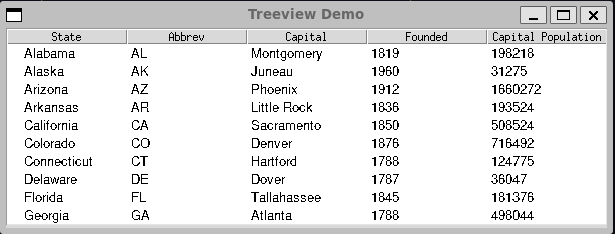
  <figcaption aria-hidden="true">A simple <code>Treeview</code> widget
  showing the state data</figcaption>
  </figure>

#### Inserting Tree Nodes

- How do we handle creating a tree structure with nested nodes?

  - Row’s return nodes when created
  - We can then use this node as an argument for subsequent child rows

- For example, rather than displaying the capital city population at the
  same level as the other data, we might prefer to nest this under the
  capital city

- First we have to play around with our data

  - We need to exclude `"Capital Population"` from the headings

    ``` python
        # slice off the first header since that's column #0
        columns = tuple([col for col in self.header[1:] if col != "Capital Population"])
    ```

  - Then we need to update how we pass values to the rows to create a
    list containing the values for the main row

  - Then also create an appropriately padded row so that the capital
    city population appears below the capital city

  - We then create our first row as normal, but this time retrieve it’s
    identifier

    - We then create the sub-row and insert it as a child our parent row

    ``` python
        # insert the data rows
        for idx, state in enumerate(self.states):
            main_row_values = []
            sub_row_values = []

            for key, value in state.to_dict().items():
                if key == "State" or key == "Capital Population":
                    continue
                elif key == "Capital":
                    main_row_values.append(value)
                    sub_row_values.append(f"pop={state.population}")
                else:
                    main_row_values.append(value)
                    sub_row_values.append("")
    ```

- This should result in a program that looks like the following,

  ``` python
    # insert the data rows
    for idx, state in enumerate(self.states):
        main_row_values = []
        sub_row_values = []

        for key, value in state.to_dict().items():
            if key == "State" or key == "Capital Population":
                continue
            elif key == "Capital":
                main_row_values.append(value)
                sub_row_values.append(f"pop={state.population}")
            else:
                main_row_values.append(value)
                sub_row_values.append("")

        state_row = tree.insert("", idx, text=state.name, values=main_row_values)
        tree.insert(state_row, tk.END, values=sub_row_values)
  ```

- The resulting `Treeview` should then look like below

  <figure>
  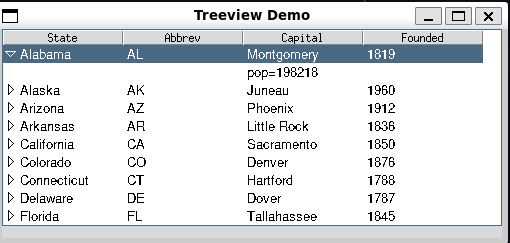
  <figcaption aria-hidden="true">A treeview with nested rows for the
  populations of the given capital cities</figcaption>
  </figure>

- The full code is found in
  [07-nested-treeview.py](Examples/07-nested-treeview/nested-treeview.png)

## Summary

- Tkinter has a number of widgets that can be data-driven or used to
  display data
- The basic `Label` can be linked to data to update what it displays
- `Listbox` and `Combobox` give you the ability to select from a list of
  strings
- `Treeview` can be used to view tabular or nested data